# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform differentiable ray tracing to compute the derivatives of the image intensity with respect to key parameters, such as:  

- Observer inclination (`θ`)
- Rhigh

We then use these derivatives to recover the ground truth parameters of our analytical test model using the conjugate gradient algorithm.  

This approach allows us to perform gradient-based parameter estimation, linking observed intensity changes directly to the underlying physical parameters.

In this notebook, we will show you how to perform the generation of the gradients. We do advise you to run the optimization via script rather than a jupyter notebook for stability.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
using Jipole
using StaticArrays

const MBH = 6.2e9

[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413](cache misses: include_dependency fsize change (1))
[ Info: Precompiling Jipole [2347fae0-cb17-4e37-b3ba-1e469be55413] (cache misses: include_dependency fsize change (2))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
[ Info: Chandra table loaded successfully from /home/mottapn/current/Jipole/src/models/../../Tables/ch24_vals.txt


6.2e9

## Magnetization parameters

We begin by defining a set of parameters that will be used when reading and processing the GRMHD simulation data

- `Rhigh:` Ratio of ion-to-electron temperature in low-magnetization regions (disk-dominated plasma). This controls how hot electrons are relative to ions in the bulk flow.
- `Rlow:` Ion-to-electron temperature ratio in highly magnetized regions (jet-dominated plasma). A value closer to 1 implies electrons and ions have similar temperatures.
- `beta_crit:` Critical plasma beta (ratio of gas pressure to magnetic pressure) that determines the transition between disk-like and jet-like thermodynamic prescriptions.
- `th_beg:`   Lower cutoff for the polar angle (in radians), typically used to exclude regions too close to the poles where numerical artifacts or low-density funnels may exist.
- `sigma_cut:` Magnetization threshold (σ = magnetic energy density / matter energy density) above which zones may be excluded or treated differently due to strong magnetic dominance.
- `sigma_cut_high:` Upper magnetization cutoff. A negative value typically indicates that no upper limit is enforced.

In [2]:
dump_filepath = "/home/mottapn/torus.out0.00200.h5"


"/home/mottapn/torus.out0.00200.h5"

In [3]:
#TODO: put this in reading file
const Rhigh = 20. 
const Rlow = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.
const sigma_cut_high = -1.0;



In [4]:
const model = Jipole.Iharm.read_header(dump_filepath, MBH;
    th_beg=th_beg, Rlow=Rlow, Rhigh=Rhigh,beta_crit=beta_crit,
    sigma_cut=sigma_cut, sigma_cut_high=sigma_cut_high,
    M_unit=Jipole.Constants.M_UNIT_MAD);  # SANE dump (see the M_unit note above)

Initializing grid from: /home/mottapn/torus.out0.00200.h5


custom electron model loaded from dump file...
Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.165908 Rout: 1000.000000
Grid start (startx): 1.535001367961415e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.638380914916404e-02, 7.812500000000000e-03, 4.908738521234052e-02


In [5]:
# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const res = 128
const pixels_x = 128
const pixels_y = 128

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * Jipole.Constants.PC

# Radius where ray integration stops
const Rstop = 100.0

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - model.a * model.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160
const DYsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0

#Number of maximum steps in the geodesic calculation
const maxnstep = 15000;

## (:MBH, :Rhigh, :Rlow, :beta_crit, :th_beg, :sigma_cut, :sigma_cut_high,  :M_unit, :ro, :th, :phi, :source), this is the entire list of parameters that can be differentiable)

In [7]:
ctx = Jipole.Iharm.load_grmhd_context("/home/mottapn/torus.out0.00200.h5")

Image, grads = Jipole.Iharm.calculate_gradients(ctx, freq, pixels_x, pixels_y, 160.0, maxnstep, xoff, yoff;
    MBH=MBH, Rhigh=Rhigh, Rlow=Rlow, beta_crit=beta_crit, th_beg=th_beg, sigma_cut=sigma_cut, sigma_cut_high=sigma_cut_high,
    M_unit=Jipole.Constants.M_UNIT_MAD, ro=ro, th=th, phi=phi, sourceD=SourceD,
    wrt=(:th, :Rhigh, :M_unit, :Rlow));

Initializing grid from: /home/mottapn/torus.out0.00200.h5
Loading data from '/home/mottapn/torus.out0.00200.h5' into 'Iharm' module...


custom electron model loaded from dump file...
Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.165908 Rout: 1000.000000
Grid start (startx): 1.535001367961415e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.638380914916404e-02, 7.812500000000000e-03, 4.908738521234052e-02


All primitives successfully loaded. Dimensions: (256, 128, 128)
Allocating workspaces for 128 row-tasks...
Tracing Geodesics...


Raytracing Image... 100%|██████████████████████████████| Time: 0:00:05 ( 0.33 ms/it)


# Plotting the Image

### Image and Sensitivity Maps

This figure shows a **1×3 panel visualization** of the simulated image and its parameter sensitivities. The horizontal and vertical axes correspond to the **angular coordinates on the sky (in μas)**.


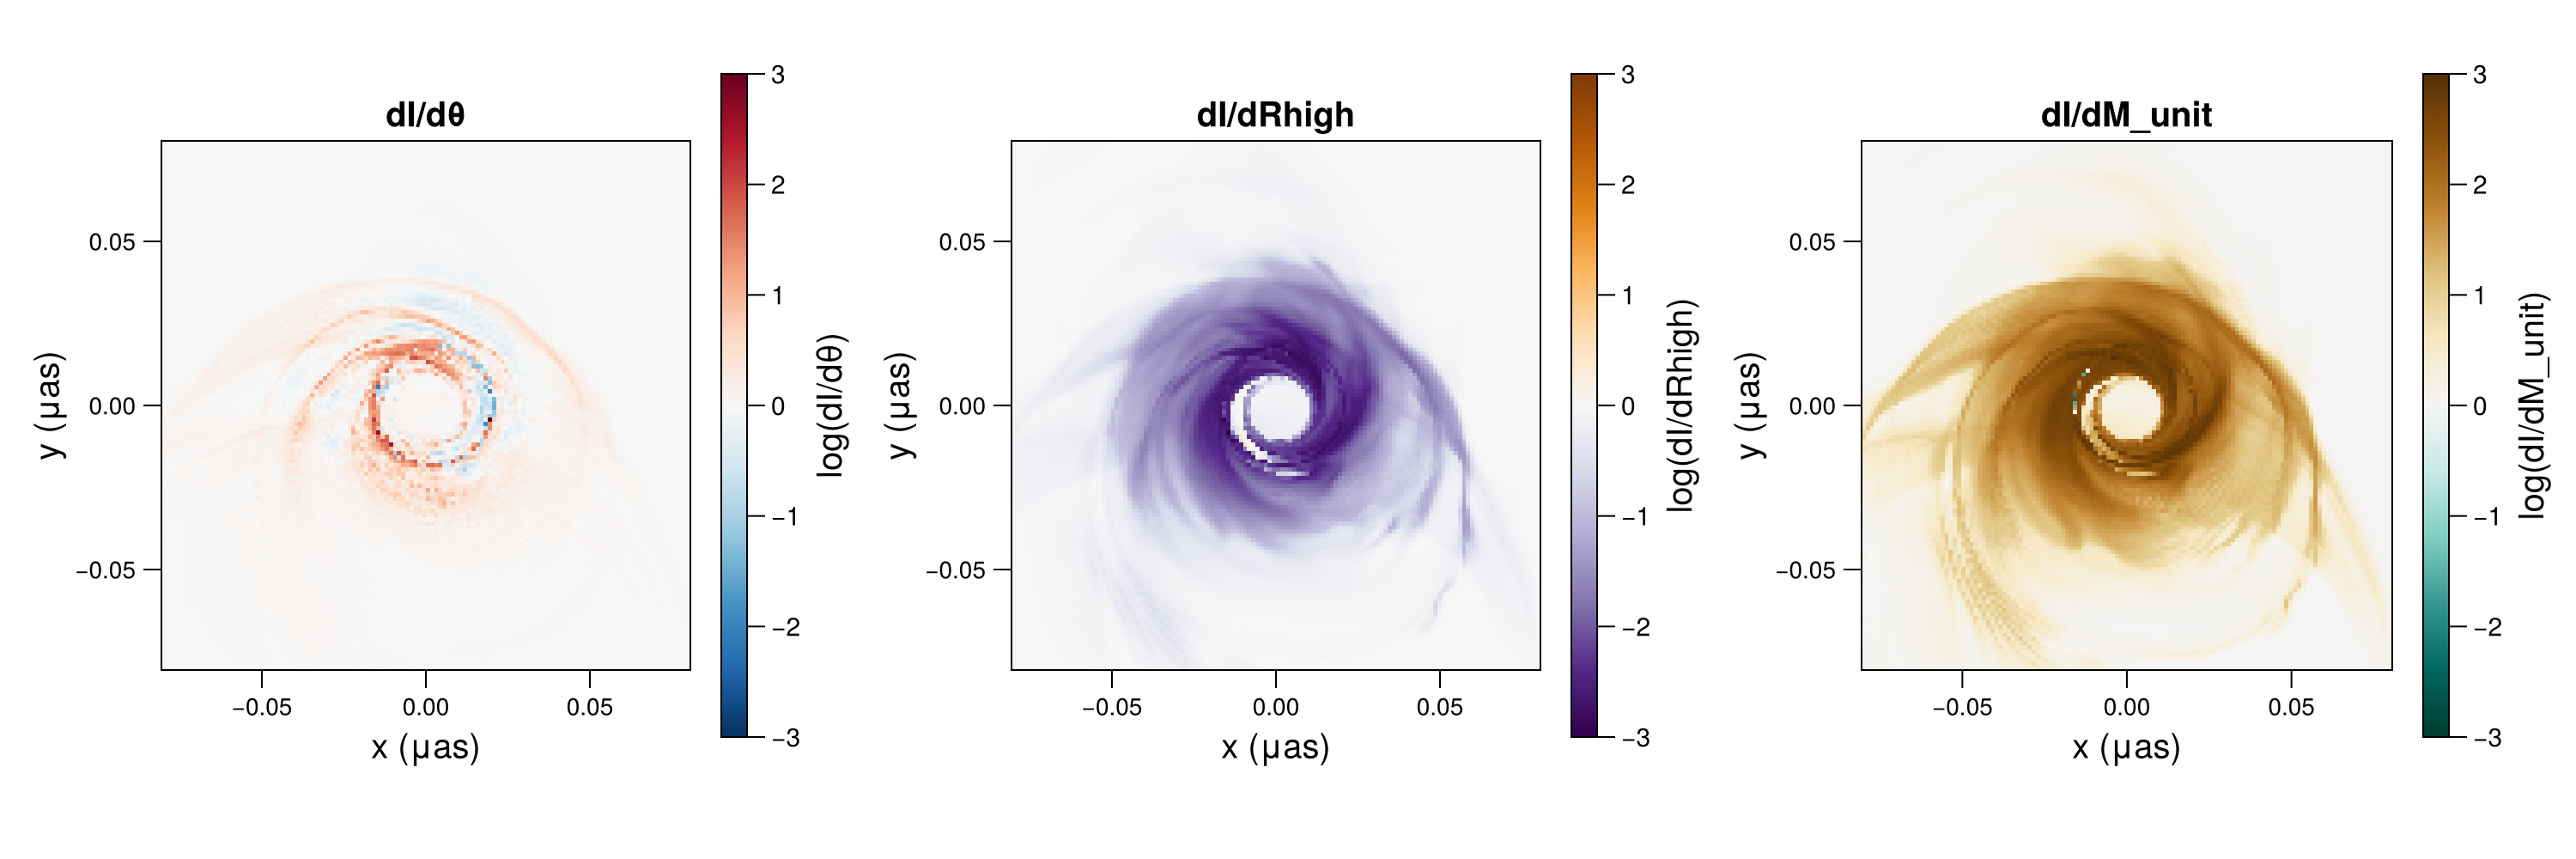

In [12]:
using CairoMakie

d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = fovx
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD

x_coords = range(-theta_μas, theta_μas, length=pixels_x)
y_coords = range(-theta_μas, theta_μas, length=pixels_y)

function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

axis_tick_size = 14
colorbar_tick_size = 15
colorbar_label_size = 20

max_val_theta = maximum(abs.(filter(!isnan, grads[1])))
if max_val_theta == 0; max_val_theta = 1.0; end

vmin_theta = -max_val_theta
vmax_theta = max_val_theta
linthresh_theta = 1e-2 * vmax_theta

dI_dθ_symlog = symlog(grads[1]; linthresh=linthresh_theta)
cr_symlog_theta = (-(1 + log10(abs(vmin_theta) / linthresh_theta)), (1 + log10(abs(vmax_theta) / linthresh_theta)))

max_val_R = maximum(abs.(filter(!isnan, grads[2])))
if max_val_R == 0; max_val_R = 1.0; end

vmin_R = -max_val_R
vmax_R = max_val_R
linthresh_R = 1e-2 * vmax_R

dI_dR_symlog = symlog(grads[2]; linthresh=linthresh_R)
cr_symlog_R = (-(1 + log10(abs(vmin_R) / linthresh_R)), (1 + log10(abs(vmax_R) / linthresh_R)))

max_val_M = maximum(abs.(filter(!isnan, grads[3])))
if max_val_M == 0; max_val_M = 1.0; end

vmin_M = -max_val_M
vmax_M = max_val_M
linthresh_M = 1e-2 * vmax_M

dI_dM_symlog = symlog(grads[3]; linthresh=linthresh_M)
cr_symlog_M = (-(1 + log10(abs(vmin_M) / linthresh_M)), (1 + log10(abs(vmax_M) / linthresh_M)))

fig = Figure(size=(1500, 500))

ax1 = Axis(fig[1, 1], title="dI/dθ", xlabel="x (μas)", ylabel="y (μas)", aspect=DataAspect(), titlesize=20, xlabelsize=20, ylabelsize=20, xticklabelsize=axis_tick_size, yticklabelsize=axis_tick_size, xticksize=10, yticksize=10)
hm1 = heatmap!(ax1, x_coords, y_coords, dI_dθ_symlog; colormap=Reverse(:RdBu), colorrange=cr_symlog_theta)
cb1 = Colorbar(fig[1, 2], hm1; label="log(dI/dθ)", labelsize=colorbar_label_size, ticklabelsize=colorbar_tick_size, ticksize=10, width=15)

ax2 = Axis(fig[1, 3], title="dI/dRhigh", xlabel="x (μas)", ylabel="y (μas)", aspect=DataAspect(), titlesize=20, xlabelsize=20, ylabelsize=20, xticklabelsize=axis_tick_size, yticklabelsize=axis_tick_size, xticksize=10, yticksize=10)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_dR_symlog; colormap=Reverse(:PuOr), colorrange=cr_symlog_R)
cb2 = Colorbar(fig[1, 4], hm2; label="log(dI/dRhigh)", labelsize=colorbar_label_size, ticklabelsize=colorbar_tick_size, ticksize=10, width=15)

ax3 = Axis(fig[1, 5], title="dI/dM_unit", xlabel="x (μas)", ylabel="y (μas)", aspect=DataAspect(), titlesize=20, xlabelsize=20, ylabelsize=20, xticklabelsize=axis_tick_size, yticklabelsize=axis_tick_size, xticksize=10, yticksize=10)
hm3 = heatmap!(ax3, x_coords, y_coords, dI_dM_symlog; colormap=Reverse(:BrBG), colorrange=cr_symlog_M)
cb3 = Colorbar(fig[1, 6], hm3; label="log(dI/dM_unit)", labelsize=colorbar_label_size, ticklabelsize=colorbar_tick_size, ticksize=10, width=15)

fig

# GPU version

In [1]:
using Jipole
using StaticArrays

const MBH = 6.2e9

6.2e9

In [2]:
dump_filepath ="/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"


"/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5"

In [3]:
Rhigh = 20. 
const Rlow = 1. 
const beta_crit = 1.0 
const th_beg = 1.74e-2 
const sigma_cut = 1.e99
const sigma_cut_high = -1.0;

In [4]:
const model = Jipole.Iharm.read_header(dump_filepath, MBH;
    th_beg=th_beg, Rlow=Rlow, beta_crit=beta_crit,
    sigma_cut=sigma_cut, sigma_cut_high=sigma_cut_high,
    M_unit=Jipole.Constants.M_UNIT_SANE);  # SANE dump -- see the M_unit note above

Initializing grid from: /home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5


Using Modified Kerr-Schild coordinates MKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.177706 Rout: 1000.000000
Grid start (startx): 1.635684465252566e-01, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 2.341731539047528e-02, 7.812500000000000e-03, 4.908738521234052e-02


In [5]:
const simulation_data = Vector{Jipole.Iharm.IharmData{Array{Float64, 3}}}(undef, 1)
simulation_data[1] = Jipole.Iharm.load_data(dump_filepath, Rhigh, model);

Loading data from '/home/pedro/sample_dump_SANE_a+0.94_MKS_0900.h5' into 'Iharm' module...
All primitives successfully loaded. Dimensions: (288, 128, 128)


In [6]:
# Observer distance in gravitational radii (Rg)
const ro = 1000.0

# Inclination angle (deg) — angle between the observer and the BH spin axis
const th = 163.0

# Azimuthal angle (deg) — rotation around the system
const phi = 0.0

# Image resolution — total geodesics traced = res^2
const res = 128
const pixels_x = 128
const pixels_y = 128

# Distance to the source (in parsecs, converted to code units)
const SourceD = 16.9e6 * Jipole.Constants.PC

# Radius where ray integration stops
const Rstop = 100.0

# Event horizon radius for a Kerr black hole
const Rh = 1 + sqrt(1. - model.a * model.a)

# Observing frequency (Hz), e.g. 230 GHz for EHT-like images
const freq = 230e9

# Image plane size (in Rg), scaled from physical distance
const DXsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160
const DYsize = SourceD / model.L_unit / Jipole.Constants.MUAS_PER_RAD * 160

# Field of view (radians)
const fovx = DXsize / ro
const fovy = DYsize / ro

# Image offsets (can be used to shift the camera)
const xoff = 0.0
const yoff = 0.0

#Number of maximum steps in the geodesic calculation
const maxnstep = 15000;

In [9]:
using CUDA
#First, we clear the arrays
d_Image = nothing
d_dI_dθo = nothing
d_dI_dRhigh = nothing
d_traj = nothing
gpu_sim_data = nothing

# Then we allocate Image
d_Image       = CUDA.zeros(Float64, pixels_x, pixels_y)
d_dI_dθo      = CUDA.zeros(Float64, pixels_x, pixels_y)
d_dI_dRhigh   = CUDA.zeros(Float64, pixels_x, pixels_y)
block_size = 64
d_traj = CuArray{Jipole.GeoTypes.OfTrajGRMHD}(undef, block_size, block_size, maxnstep)
threads_per_block = (4, 4)
blocks_per_grid   = (cld(block_size, threads_per_block[1]), cld(block_size, threads_per_block[2]))

println("Copying simulation data grids to the GPU...")

gpu_sim_data = (Jipole.Utils_GPU.copy_iharm_to_gpu(simulation_data[1]),)
gpu_params = model;

Copying simulation data grids to the GPU...


In [10]:
println("Processing image in tiles...")

CUDA.@time begin
    # Loop over the image grid in steps of block_size
    for i_offset in 0:block_size:(pixels_x - 1)
        for j_offset in 0:block_size:(pixels_y - 1)
            
            @cuda threads=threads_per_block blocks=blocks_per_grid Jipole.Autodiff.raytrace_gradients_gpu!(
                d_traj, d_Image,d_dI_dθo, d_dI_dRhigh,
                i_offset, j_offset, block_size, block_size,
                ro, th, phi, model.a, pixels_x, pixels_y, maxnstep,
                freq, fovx, fovy, model.Rout, Rstop, gpu_sim_data, gpu_params
            )
            
        end
    end
    CUDA.synchronize()
end

h_Image = Array(d_Image)
h_dI_dth = Array(d_dI_dθo)
h_dI_drhigh = Array(d_dI_dRhigh)

println("Raytracing complete!")

Processing image in tiles...
  7.040986 seconds (1.01 k CPU allocations: 48.750 KiB, 0.03% gc time)
Raytracing complete!


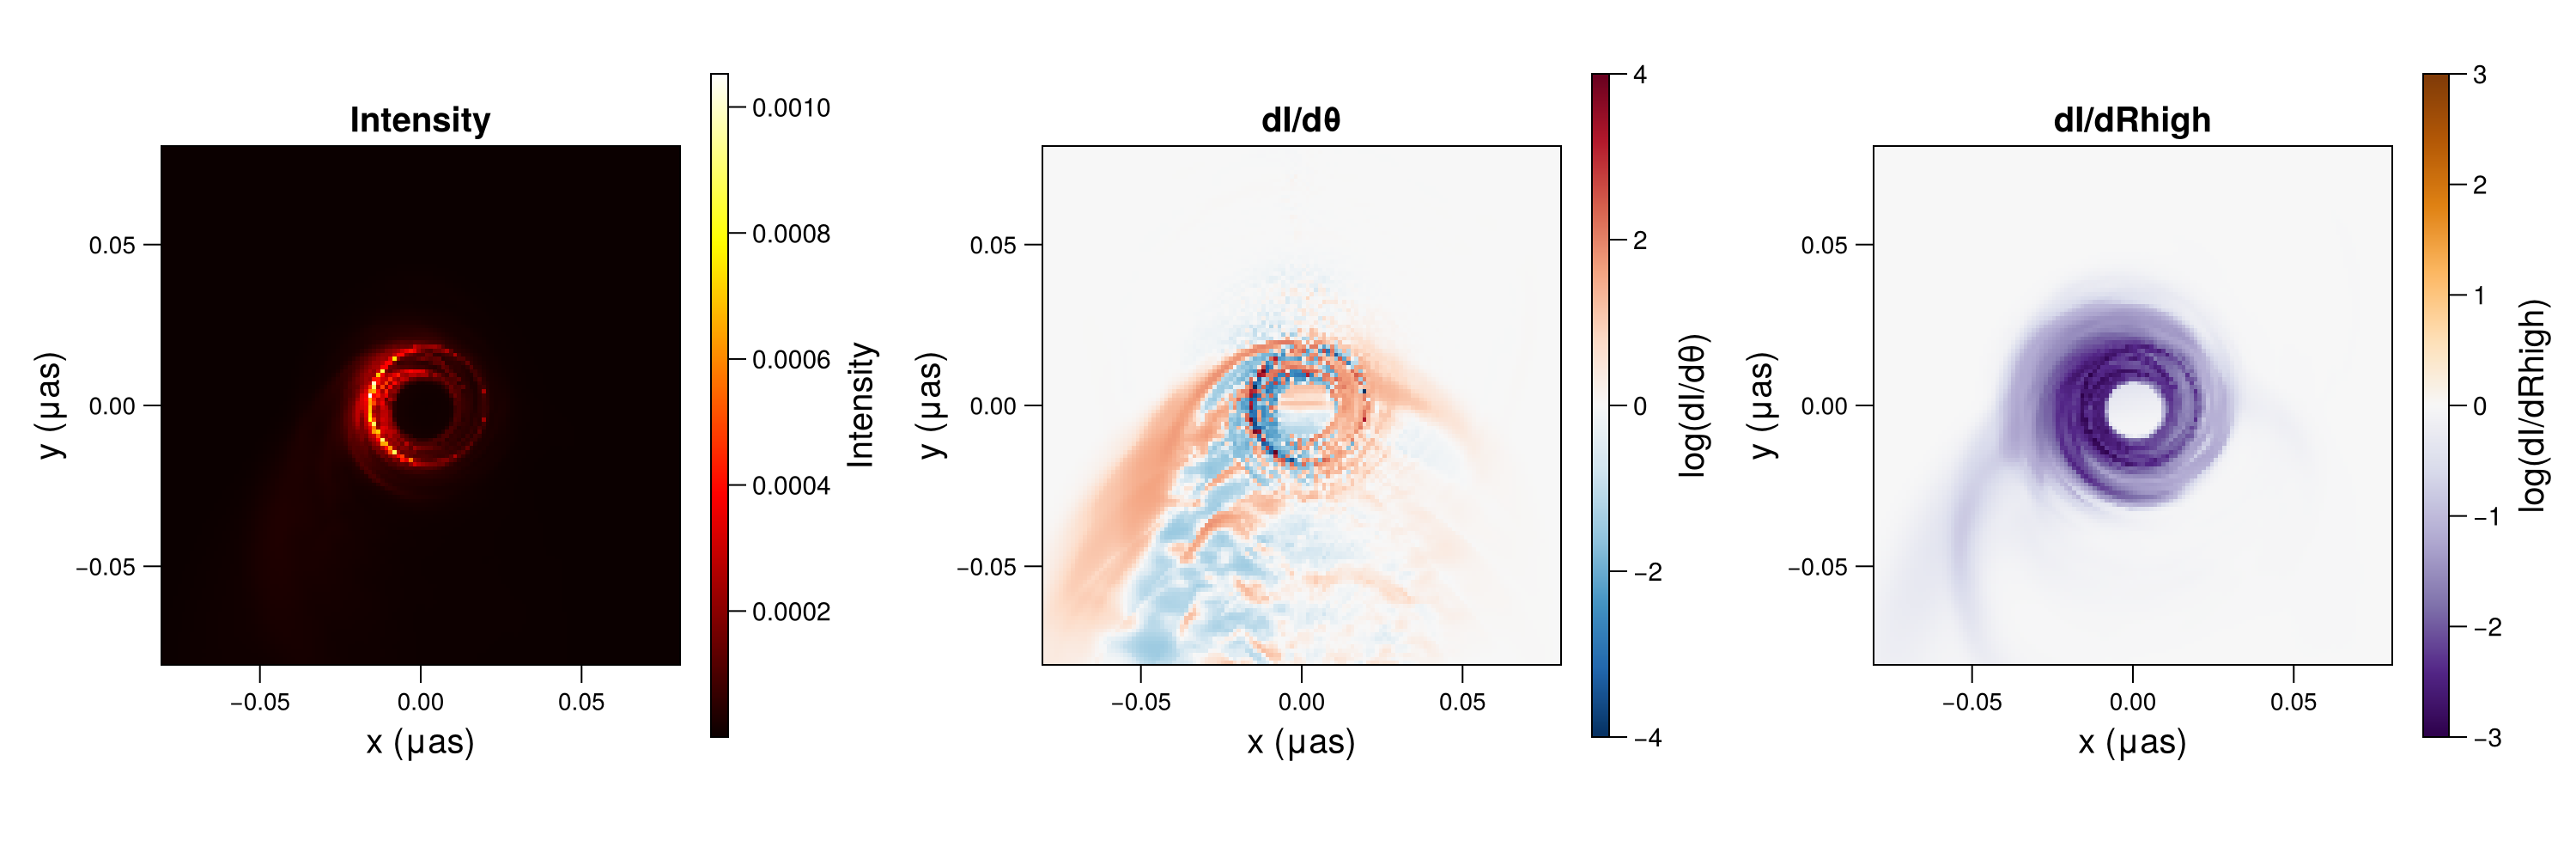

In [11]:
using CairoMakie

d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = fovx
half_fov_rg = fov_rg / 2

theta_rad = (half_fov_rg * model.L_unit) / d_cm
theta_μas = theta_rad * Jipole.Constants.MUAS_PER_RAD

x_coords = range(-theta_μas, theta_μas, length=pixels_x)
y_coords = range(-theta_μas, theta_μas, length=pixels_y)


function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end


axis_tick_size = 14
colorbar_tick_size = 15
colorbar_label_size = 20


vmin_theta = -1e-3
vmax_theta =  1e-3
linthresh_theta = 1e-3 * vmax_theta

dI_dθ_symlog = symlog(h_dI_dth; linthresh=linthresh_theta)
cr_symlog_theta = (
    -(1 + log10(abs(vmin_theta) / linthresh_theta)),
     (1 + log10(abs(vmax_theta) / linthresh_theta))
)

max_val_R = maximum(abs.(filter(!isnan, h_dI_drhigh))) 
if max_val_R == 0; max_val_R = 1.0; end 

vmin_R = -max_val_R
vmax_R =  max_val_R
linthresh_R = 1e-2 * vmax_R 

dI_dR_symlog = symlog(h_dI_drhigh; linthresh=linthresh_R)
cr_symlog_R = (
    -(1 + log10(abs(vmin_R) / linthresh_R)),
     (1 + log10(abs(vmax_R) / linthresh_R))
)

fig = Figure(size = (1500, 500)) 

ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm1 = heatmap!(ax1, x_coords, y_coords, h_Image; colormap = :hot)
cb1 = Colorbar(fig[1, 2], hm1; 
    label = "Intensity",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                    
    width = 10                         
)


ax2 = Axis(fig[1, 3],
    title = "dI/dθ",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)
hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog_theta
)
cb2 = Colorbar(fig[1, 4], hm2; 
    label = "log(dI/dθ)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size,
    ticksize = 10,                     
    width = 10                        
)
ax3 = Axis(fig[1, 5],
    title = "dI/dRhigh",
    xlabel = "x (μas)", ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize = 20, xlabelsize = 20, ylabelsize = 20,
    xticklabelsize = axis_tick_size,
    yticklabelsize = axis_tick_size,
    xticksize = 10, yticksize = 10 
)

hm3 = heatmap!(ax3, x_coords, y_coords, dI_dR_symlog;
    colormap = Reverse(:PuOr), 
    colorrange = cr_symlog_R
)

cb3 = Colorbar(fig[1, 6], hm3; 
    label = "log(dI/dRhigh)",
    labelsize = colorbar_label_size,   
    ticklabelsize = colorbar_tick_size, 
    ticksize = 10,                     
    width = 15                        
)

fig